# 1. Dataset Prepration 

In [2]:
import os
import re
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [3]:
DATA_PATH = "/kaggle/input/datasets/crawford/20-newsgroups"

# Get all newsgroup text files
files = [f for f in os.listdir(DATA_PATH) if f.endswith(".txt")]

print("Number of files:", len(files))
print(files)

Number of files: 20
['misc.forsale.txt', 'rec.autos.txt', 'comp.os.ms-windows.misc.txt', 'sci.electronics.txt', 'comp.sys.mac.hardware.txt', 'talk.politics.mideast.txt', 'talk.politics.guns.txt', 'talk.religion.misc.txt', 'comp.graphics.txt', 'soc.religion.christian.txt', 'rec.sport.hockey.txt', 'rec.sport.baseball.txt', 'comp.windows.x.txt', 'comp.sys.ibm.pc.hardware.txt', 'rec.motorcycles.txt', 'sci.med.txt', 'sci.space.txt', 'alt.atheism.txt', 'sci.crypt.txt', 'talk.politics.misc.txt']


In [9]:
# Load documents and labels\
documents = []
labels = []

for file in files:
    label = file.replace(".txt", "")
    
    with open(os.path.join(DATA_PATH, file), "r", encoding="latin1") as f:
        content = f.read()
    
    # Each message starts with "Newsgroup:"
    messages = re.split(r"(?=Newsgroup:)", content)
    
    for message in messages:
        message = message.strip()
        
        if message:
            documents.append(message)
            labels.append(label)

df = pd.DataFrame({
    "text": documents,
    "label": labels
})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (37662, 2)


,text,label
0,Newsgroup: misc.forsale\ndocument_id: 70337\nF...,misc.forsale
1,Newsgroup: misc.forsale\ndocument_id: 74150\nF...,misc.forsale
2,Newsgroup: misc.forsale\ndocument_id: 74720\nF...,misc.forsale
3,Newsgroup: misc.forsale\ndocument_id: 74721\nF...,misc.forsale
4,Newsgroup: misc.forsale\ndocument_id: 74722\nF...,misc.forsale


In [13]:
# Beofre cleaning 

for i in range(5):
    print(f"\n{'='*20} DOCUMENT {i} {'='*20}")
    print(df["text"].iloc[i])


==================== DOCUMENT 0 ====================
Newsgroup: misc.forsale
document_id: 70337
From: kedz@bigwpi.WPI.EDU (John Kedziora)
Subject: Motorcycle wanted.

Sender: 
Followup-To:kedz@wpi.wpi.edu 
Distribution: ne
Organization: Worcester Polytechnic Institute
Keywords: 

I am looking for an inexpensive motorcycle, nothing fancy, have to be able to do all maintinence my self. looking in the <$400 range.

if you can help me out, GREAT!, please reply by e-mail.

==================== DOCUMENT 1 ====================
Newsgroup: misc.forsale
document_id: 74150
From: myoakam@cis.ohio-state.edu (micah r yoakam)
Subject: BOAT for SALE

BOAT For SALE
1989 23' IMPERIAL FISHERMAN featuring
        Walkaround Cuddy Cabin, 305 V8 with VOLVO DUO PROP OUTDRIVE /\/\/\/
AM-FM Cassette Stereo, VHF RADIO, 4x6 HUMMINGBIRD Fishfinder, ALL  Safty
equipment, Covers, and MUCH MORE.  
        18000 LB.  Capacity
        includes Storage Trailer
        Hardly used:  LESS Than 100 Hrs

Asking: $15,000 O

In [16]:
import re

def clean_text(text):

    # 1. Remove headers but keep Subject
    text = re.sub(
        r"^Newsgroup:.*?\n"
        r"document_id:.*?\n"
        r"From:.*?\n"
        r"Subject:\s*",
        "",
        text,
        flags=re.IGNORECASE | re.DOTALL
    )

    # 2. Remove remaining metadata headers
    text = re.sub(
        r"^(Sender:.*?\n|Followup-To:.*?\n|Distribution:.*?\n|Organization:.*?\n|Keywords:.*?\n)+",
        "",
        text,
        flags=re.IGNORECASE | re.MULTILINE
    )

    # 3. Remove quoted lines
    text = re.sub(r"(?m)^>.*$\n?", "", text)

    # 4. Remove signature
    text = re.split(r"(?m)^--\s*$", text)[0]

    # 5. Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # 6. Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # 7. Remove phone numbers
    text = re.sub(r"\b(?:\+?\d[\d\s().-]{7,}\d)\b", " ", text)

    # 8. Remove numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # 9. Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 10. Convert to lowercase
    text = text.lower()

    # 11. Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [17]:
df["text"] = df["text"].apply(clean_text)

for i in range(5):
    print(f"\n{'='*20} CLEANED DOCUMENT {i} {'='*20}")
    print(df["text"].iloc[i])


==================== CLEANED DOCUMENT 0 ====================
motorcycle wanted i am looking for an inexpensive motorcycle nothing fancy have to be able to do all maintinence my self looking in the range if you can help me out great please reply by e mail

==================== CLEANED DOCUMENT 1 ====================
boat for sale boat for sale imperial fisherman featuring walkaround cuddy cabin v with volvo duo prop outdrive am fm cassette stereo vhf radio x hummingbird fishfinder all safty equipment covers and much more lb capacity includes storage trailer hardly used less than hrs asking or best offer for further information contact gerald at mansfield oh

==================== CLEANED DOCUMENT 2 ====================
wanted brother p touch as it says i m interested in buying one of the little label makers and i can t afford a new one anybody tired of theirs e mail maureen

==================== CLEANED DOCUMENT 3 ====================
make your own talking elevators complete standalone 

In [20]:
#Train / Validation / Test split
X = df["text"]
y = df["label"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 26363
Validation: 5649
Test: 5650


# 2. EDA


In [21]:
# Count documents in each newsgroup
class_counts = df["label"].value_counts().sort_index()

print(class_counts)

label
alt.atheism                 1599
comp.graphics               1947
comp.os.ms-windows.misc     1970
comp.sys.ibm.pc.hardware    1964
comp.sys.mac.hardware       1922
comp.windows.x              1960
misc.forsale                1944
rec.autos                   1980
rec.motorcycles             1988
rec.sport.baseball          1988
rec.sport.hockey            1998
sci.crypt                   1982
sci.electronics             1966
sci.med                     1980
sci.space                   1974
soc.religion.christian      1994
talk.politics.guns          1820
talk.politics.mideast       1880
talk.politics.misc          1550
talk.religion.misc          1256
Name: count, dtype: int64


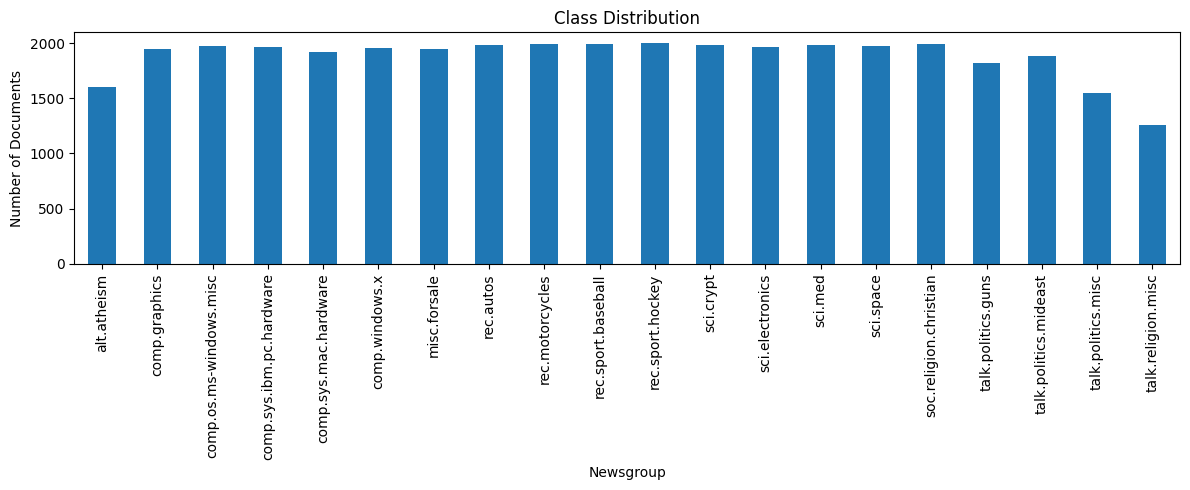

In [22]:
import matplotlib.pyplot as plt

# Plot number of documents per class
class_counts.plot(kind="bar", figsize=(12, 5))

plt.title("Class Distribution")
plt.xlabel("Newsgroup")
plt.ylabel("Number of Documents")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3. Baseline Model — ANN + TF-IDF

1. Dataset Preparation
Load dataset
Remove headers, footers, and quotes if we decide they are unwanted metadata
EDA:
Class distribution
Document length
Basic text cleaning
Train / Validation / Test split
2. Baseline Model — ANN + TF-IDF
TF-IDF feature extraction
Try a few max_features values if needed
Prepare ANN input
ANN architecture:
Input → Dense + ReLU → Dropout → Output + Softmax
Adam optimizer
Categorical cross-entropy
Early stopping
Train and monitor epochs
3. Evaluation & Diagnostics
Accuracy
Precision
Recall
Macro F1
Weighted F1
Train/validation learning curves
Confusion matrix
Analyze which classes are confused with each other
Record baseline findings